# Compute $\pi$ by throwing darts

<img src="https://jhetrick.io/Math_Day2026/dart_board.jpg?random=1" width=300>

$~$

#### Given

<img src="https://jhetrick.io/Math_Day2026/square_circle.png" width=250>

- Area of a square with size $2r$: $~~~4r^2$
- Area of a circle with radius $r$: $~~~\pi r^2$
- Ratio of Areas: $\displaystyle{ f = \frac{\pi r^2}{4r^2} = \frac{\pi}{4}}$

$~$

---

#### Procedure

<img src="https://jhetrick.io/Math_Day2026/100pts.jpg" width=300>

* Throw $N$ darts <u>*randomly*</u> at a square dartboard of size 2$\times$2 (area = 4)
* Count the number that lie inside a circle of radius $r=1$.

* Compute the fraction $\displaystyle{ f = \frac{{\rm \#~inside}~\bigcirc}{N} \approx \frac{\pi}{4} }$
* Then estimate: $\pi \approx 4*f$



## Let's do it!

We'll use Python and program a simulation of random "darts", points on a square.

First, import some python libraries we need.  
`numpy` for fast numerical vector and matrix operations  
`matplotlib` for graphics

In [24]:
import numpy as np
import matplotlib.pyplot as plt

In [83]:
# Uncomment to make the random number sequence reproducable every time you run this notebook
#np.random.seed(111)

---

### Intro to `numpy` arrays

1-dimensional arrays: a **vector**

In [73]:
v = np.arange(1,10,2)
v

array([1, 3, 5, 7, 9])

<img src="https://www.programiz.com/sites/tutorial2program/files/numpy-array-index.png" width=500>

In [81]:
v[3]

7

A *slice* of an array:

In [75]:
v[:3]

array([1, 3, 5])

---

2-dimensional arrays: a **matrix**

In [31]:
M = np.random.randint(0,100,size=(3,5))
M

array([[33, 77, 29, 28, 51],
       [75, 87, 44, 57, 52],
       [75, 12,  2, 67, 39]])

In [40]:
#M[1,3]

A slice of a matrix:

In [38]:
M[:,2]

array([29, 44,  2])

---

#### `numpy` has many *easy-to-use* functions for common tasks 

The average (mean) of all numbers in M

In [34]:
M.mean()

48.53333333333333

The mean of each *column*:

In [35]:
M.mean(axis=0)

array([61.   , 58.667, 25.   , 50.667, 47.333])

The mean of each *row*:

In [36]:
M.mean(axis=1)

array([43.6, 63. , 39. ])

---

3-dimensional arrays: a **tensor**

<img src="https://jhetrick.io/Math_Day2026/tensor.png" width=200>

In [66]:
M = np.random.randint(0,100,size=(3,4,5))
M

array([[[85, 35, 88, 76, 31],
        [79, 38, 97, 95,  2],
        [77, 42, 53, 63, 24],
        [82, 29, 69, 32, 45]],

       [[65, 97, 90, 37, 21],
        [92, 76, 19, 42, 81],
        [89, 48, 63, 65, 86],
        [75, 29, 18, 85,  1]],

       [[89, 29,  4, 82, 33],
        [40, 48, 83, 51, 96],
        [41, 62,  1, 78, 90],
        [75, 11, 74, 83, 46]]])

In [37]:
#M[1,2,3]

---

$~$

## Throw 10 Darts at a board

#### N=10 "darts" (points).

Each row of the matrix `pts` are the (x,y) coordinates of a point. 

In [87]:
N = 10
pts = np.random.uniform(-1,1,size=(N,2))
pts

array([[ 0.33484, -0.75667],
       [-0.44598, -0.8752 ],
       [ 0.13648,  0.05747],
       [ 0.30848,  0.49965],
       [ 0.61153, -0.90881],
       [-0.20972, -0.9173 ],
       [ 0.04053, -0.18564],
       [-0.51981,  0.77704],
       [ 0.95806, -0.29733],
       [-0.45194, -0.05145]])

### How many of these points are inside the circle with $r=1$?

If the $r^2 < 1$, then the point is inside the circle.  

(NOTE: We don't have to take the $\sqrt{~~}~~~$)

In [88]:
rsq = pts[:,0]**2 + pts[:,1]**2
rsq

array([0.68466, 0.96488, 0.02193, 0.34481, 1.19991, 0.88542, 0.03611,
       0.87399, 1.00628, 0.2069 ])

In [89]:
pts_inside = (rsq <= 1)
pts_inside

array([ True,  True,  True,  True, False,  True,  True,  True, False,
        True])

#### Sum the `True` points

In [90]:
pts_inside.sum()

8

In [91]:
estPi = 4 * pts_inside.sum()/N
estPi

3.2

---

$~$

### Now with graphics and more darts!

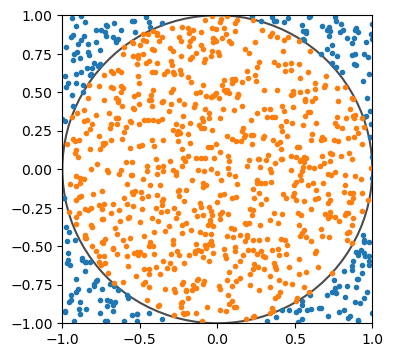

In [8]:
# "Throw" 1000 darts and find which ones are inside the circle
N = 1000

# Create an array of 1000 points
pts = np.random.uniform(-1,1,(N,2))
pts_inside = (pts[:,0]**2 + pts[:,1]**2) <= 1

# Draw the circle
plt.figure(figsize=(4,4))
theta = np.linspace(0, 2 * np.pi, 100)
x = np.cos(theta)
y = np.sin(theta)
plt.plot(x, y,'k-', alpha=0.7)

# Plot the points
plt.plot(pts[~pts_inside,0], pts[~pts_inside,1], '.')
plt.plot(pts[pts_inside,0], pts[pts_inside,1], '.')
plt.xlim(-1,1)
plt.ylim(-1,1);

### What's our estimate of $\pi$?

In [9]:
estPi = 4 * pts_inside.sum()/N
estPi

3.072

### The error of our estimate

In [10]:
np.pi

3.141592653589793

In [11]:
estPi - np.pi

-0.06959265358979305

"*Pretty close*" to the true value of $\pi$, using 1000 'darts'

#### Rerun the experiment to see how the estimate changes with a different set of 1000 random 'darts'

In [12]:
# Create an array of 1000 points
N = 1000
pts = np.random.uniform(-1,1,(N,2))
# Find the points inside the circle
pts_inside = (pts[:,0]**2 + pts[:,1]**2) <= 1
# Compute the estimated value of pi
estPi2 = 4 * pts_inside.sum()/N
print(estPi2)

3.212


In [13]:
estPi2 - np.pi

0.07040734641020707

---

$~$ 

## How does our estimate change with the number of "darts" (N) ?

Let's see how our estimate converges to the true value, as $N$ get larger.

We'll throw:
* 10
* 100
* 1000
* 10000
* 100000

darts

In [23]:
%%time 
# This let's us know the time this cell takes to execute.

N = 10
for i in range(5):
    pts = np.random.uniform(-1,1,(N,2))
    pts_inside = (pts[:,0]**2 + pts[:,1]**2) <= 1
    estPi = 4 * pts_inside.sum()/N
    print(f"10^{i+1}: N = {N}  est. pi = {estPi}  diff = {estPi-np.pi}")
    N *= 10

10^1: N = 10  est. pi = 3.2  diff = 0.05840734641020706
10^2: N = 100  est. pi = 2.88  diff = -0.2615926535897932
10^3: N = 1000  est. pi = 3.16  diff = 0.018407346410207026
10^4: N = 10000  est. pi = 3.1568  diff = 0.015207346410206934
10^5: N = 100000  est. pi = 3.15296  diff = 0.011367346410207091
CPU times: total: 0 ns
Wall time: 9.5 ms


$~$

---

$~$


<img src="https://as1.ftcdn.net/jpg/02/80/01/62/1000_F_280016249_V1hVWIIUoSM3qMliDclCsqwU2KisHZlc.webp" width=500> 

### How many darts do we have to throw in order to reliably get, at least: 3.14xxx

In other words, our error needs to be less than about:  0.0015

In [125]:
np.pi - 3.14

0.0015926535897929917

---

### You can try this on your phone!

Visit: **Monte Carlo Darts**

<img src="https://jhetrick.io/Math_Day2026/mcdarts_screen.png" width=600>

<img src="https://jhetrick.io/Math_Day2026/qr_mcpi.png" width=400>

# https://jhetrick.io/MCpi

---

## Analysis with Many Simulations 

We saw above that the if we redo the simulation with the same number of darts (1000 say), the results vary slightly.  
The more darts the smaller this variation, but it's still there.

To study this, let's do the simulation 50 times for each N, collect the results, and look at the average value for our estimate in how it varies.

In [23]:
%%time

runs = 50
max10N = 8

allsims = np.zeros((runs,max10N,2))

for r in range(runs):
    N = 10
    for i in range(max10N):
        pts = np.random.uniform(-1,1,(N,2))
        pts_inside = (pts[:,0]**2 + pts[:,1]**2) <= 1
        estPi = 4 * pts_inside.sum()/N
        allsims[r,i,:] = np.array([N, estPi])
        N *= 10

CPU times: total: 1min 17s
Wall time: 3min 37s


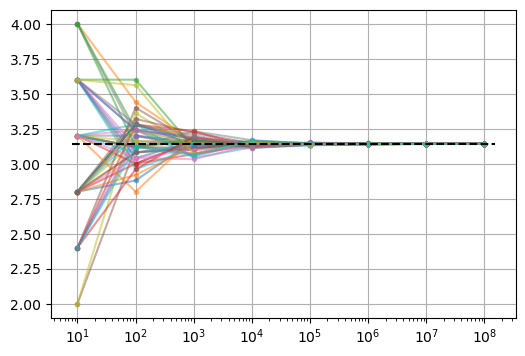

In [30]:
plt.figure(figsize=(6,4))

for r in range(runs):
    plt.plot(allsims[r,:,0], allsims[r,:,1], '.-', alpha=0.5)
    
plt.xscale('log')
plt.grid()
plt.plot([8,1.5*pow(10,max10N)], [np.pi,np.pi], 'k--')

In [31]:
# set the print precision
np.set_printoptions(precision=5, suppress=True)

In [32]:
allsims[:,0,1]

array([3.6, 4. , 4. , 3.2, 2.8, 3.6, 3.2, 4. , 2.8, 2.8, 2.8, 2.8, 2.8,
       2.8, 2.4, 2. , 3.6, 3.2, 2. , 3.6, 3.6, 2.8, 3.2, 3.2, 2.4, 2.8,
       2.8, 3.2, 3.2, 3.2, 2.8, 2.8, 3.6, 2.4, 3.6, 2.4, 2.8, 3.2, 2.8,
       3.2, 2.8, 3.2, 4. , 2.4, 3.6, 2.8, 3.2, 3.6, 3.6, 2.4])

In [33]:
allsims[:,0,1]/4

array([0.9, 1. , 1. , 0.8, 0.7, 0.9, 0.8, 1. , 0.7, 0.7, 0.7, 0.7, 0.7,
       0.7, 0.6, 0.5, 0.9, 0.8, 0.5, 0.9, 0.9, 0.7, 0.8, 0.8, 0.6, 0.7,
       0.7, 0.8, 0.8, 0.8, 0.7, 0.7, 0.9, 0.6, 0.9, 0.6, 0.7, 0.8, 0.7,
       0.8, 0.7, 0.8, 1. , 0.6, 0.9, 0.7, 0.8, 0.9, 0.9, 0.6])

#### Get a list of N values

In [41]:
allsims[0,:,0].astype(int)

array([       10,       100,      1000,     10000,    100000,   1000000,
        10000000, 100000000])

In [43]:
numpts = allsims[0,:,0]

In [45]:
numpts.sum()* 50

5555555500.0

In [46]:
180+37

217

In [47]:
(180+37)/(numpts.sum()*50)

3.9060000390600006e-08

### Minimum and maximum estimates for the 50 runs

In [48]:
allsims[:,:,1].min(axis=0)

array([2.     , 2.8    , 3.032  , 3.112  , 3.1304 , 3.13846, 3.14055,
       3.14121])

In [49]:
allsims[:,:,1].max(axis=0)

array([4.     , 3.6    , 3.232  , 3.1676 , 3.15152, 3.14452, 3.14241,
       3.14203])

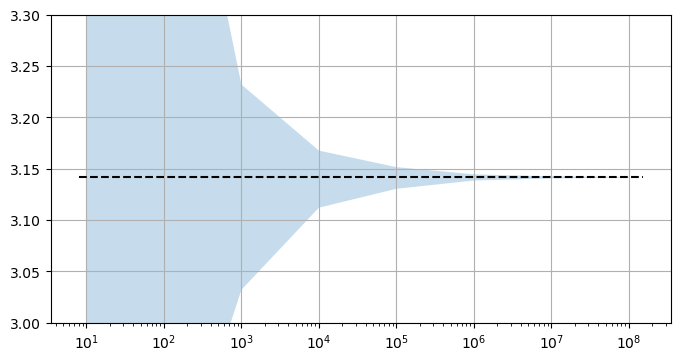

In [52]:
plt.figure(figsize=(8,4))

plt.fill_between(numpts, allsims[:,:,1].min(axis=0), allsims[:,:,1].max(axis=0), alpha=0.25)
    
plt.xscale('log')
plt.grid()
plt.ylim(3.0,3.3)
plt.plot([8,1.5*pow(10,max10N)], [np.pi,np.pi], 'k--')

### Or we can plot this as errorbars (standard deviation rather than min-max)

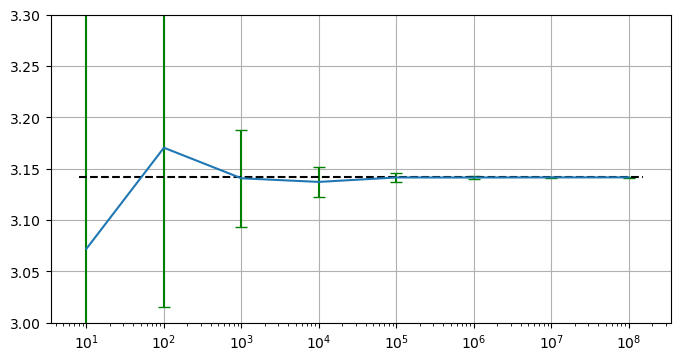

In [54]:
plt.figure(figsize=(8,4))

plt.errorbar(numpts, allsims[:,:,1].mean(axis=0), allsims[:,:,1].std(axis=0), ecolor='g', capsize=4)
    
plt.xscale('log')
plt.grid()
plt.ylim(3.0,3.3)
plt.plot([8,1.5*pow(10,max10N)], [np.pi,np.pi], 'k--')

### This is how the error on our estimate decreases as we increase the number of darts, N.

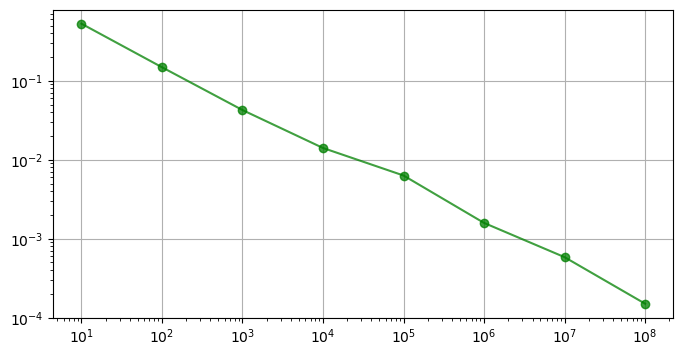

In [73]:
plt.figure(figsize=(8,4))

plt.plot(numpts, allsims[:,:,1].std(axis=0), 'go-', alpha=0.75)
    
plt.xscale('log')
plt.yscale('log')
plt.grid()


In [55]:
allsims[:,:,1].mean(axis=0)

array([3.072  , 3.1704 , 3.14064, 3.1371 , 3.14147, 3.1414 , 3.14153,
       3.14155])

In [56]:
allsims[:,:,1].mean(axis=0) - np.pi

array([-0.06959,  0.02881, -0.00095, -0.00449, -0.00012, -0.00019,
       -0.00007, -0.00004])